# Exploratory Data Analysis on County-Level Corn Yield Dataset

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)

## Load Dataset

In [3]:
df = pd.read_csv('../data/processed/corn_belt_yield_weather_soil.csv', dtype={"fips":str, "state_ansi":str, "county_ansi":str})

## Basic Data Inspection

In [4]:
df.head()

,state_name,state_alpha,state_ansi,county_ansi,fips,county_name,year,short_desc,unit_desc,statisticcat_desc,...,vp_mean_pa_m12,sand_pct_0_30cm,silt_pct_0_30cm,clay_pct_0_30cm,organic_matter_pct_0_30cm,ph_0_30cm,bulk_density_g_cm3_0_30cm,ksat_um_s_0_30cm,available_water_storage_cm_0_100cm,slope_pct
0,ILLINOIS,IL,17,11,17011,BUREAU,2025,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,357.549355,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
1,ILLINOIS,IL,17,11,17011,BUREAU,2024,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,462.975000,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
2,ILLINOIS,IL,17,11,17011,BUREAU,2023,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,614.017097,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
3,ILLINOIS,IL,17,11,17011,BUREAU,2022,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,393.786774,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
4,ILLINOIS,IL,17,11,17011,BUREAU,2021,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,504.136452,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624


In [5]:
df.tail()

,state_name,state_alpha,state_ansi,county_ansi,fips,county_name,year,short_desc,unit_desc,statisticcat_desc,...,vp_mean_pa_m12,sand_pct_0_30cm,silt_pct_0_30cm,clay_pct_0_30cm,organic_matter_pct_0_30cm,ph_0_30cm,bulk_density_g_cm3_0_30cm,ksat_um_s_0_30cm,available_water_storage_cm_0_100cm,slope_pct
24639,WISCONSIN,WI,55,133,55133,WAUKESHA,2004,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,349.899333,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24640,WISCONSIN,WI,55,133,55133,WAUKESHA,2003,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,397.107097,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24641,WISCONSIN,WI,55,133,55133,WAUKESHA,2002,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,360.261935,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24642,WISCONSIN,WI,55,133,55133,WAUKESHA,2001,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,449.862581,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936
24643,WISCONSIN,WI,55,133,55133,WAUKESHA,2000,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",BU / ACRE,YIELD,...,192.104333,32.140697,48.009876,19.708831,7.985185,6.79216,1.322462,13.59523,16.787496,5.08936


In [6]:
df.shape

(24644, 106)

In [7]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24644 entries, 0 to 24643
Data columns (total 106 columns):
 #    Column                              Dtype  
---   ------                              -----  
 0    state_name                          object 
 1    state_alpha                         object 
 2    state_ansi                          object 
 3    county_ansi                         object 
 4    fips                                object 
 5    county_name                         object 
 6    year                                int64  
 7    short_desc                          object 
 8    unit_desc                           object 
 9    statisticcat_desc                   object 
 10   Value                               float64
 11   latitude                            float64
 12   longitude                           float64
 13   prcp_total_mm_m01                   float64
 14   prcp_total_mm_m02                   float64
 15   prcp_total_mm_m03                 

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,24644.0,2011.815533,7.443268,2000.000000,2005.000000,2011.000000,2018.000000,2025.000000
Value,24644.0,147.829005,38.241255,0.000000,124.000000,151.800000,175.300000,253.600000
latitude,24644.0,41.299657,2.812696,36.211400,39.059800,40.988000,43.345900,48.814900
longitude,24644.0,-91.543901,5.702835,-103.846600,-96.177900,-91.479300,-86.446200,-80.748200
prcp_total_mm_m01,24644.0,46.268875,42.391356,0.000000,14.850000,32.025000,66.360000,283.480000
prcp_total_mm_m02,24644.0,48.823535,43.909309,0.000000,17.707500,36.840000,66.080000,343.800000
prcp_total_mm_m03,24644.0,68.422388,47.886767,0.000000,32.010000,60.490000,93.090000,444.310000
prcp_total_mm_m04,24644.0,95.190592,54.840617,0.000000,57.330000,87.870000,121.957500,493.550000
prcp_total_mm_m05,24644.0,117.017343,57.939928,0.000000,74.820000,110.435000,149.892500,479.270000
prcp_total_mm_m06,24644.0,116.753259,61.911087,0.000000,72.290000,106.540000,149.635000,552.690000


In [9]:
df.describe(include='object').T

,count,unique,top,freq
state_name,24644,13,IOWA,2470
state_alpha,24644,13,IA,2470
state_ansi,24644,13,19,2470
county_ansi,24644,122,15,315
fips,24644,1124,17011,26
county_name,24644,704,JACKSON,231
short_desc,24644,1,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",24644
unit_desc,24644,1,BU / ACRE,24644
statisticcat_desc,24644,1,YIELD,24644


The Corn Yield (`Value`) has an average of `147.829005` bushels per acre. The median corn yield is `151.8` bushels per acre. The range of yield is from `0` to `253.6` bushels per acre. The zero values will be investigated in the data quality section. The `short_desc`, `unit_desc`, and `statisticcat_desc` have a unique value of `1`. This shows that the records consistently show the corn yield in bushels per acre. 

In [10]:
df['fips'].nunique()

1124

In [11]:
df['state_alpha'].unique()

array(['IL', 'IN', 'IA', 'KS', 'KY', 'MI', 'MN', 'MO', 'NE', 'ND', 'OH',
       'SD', 'WI'], dtype=object)

In [12]:
df['state_alpha'].nunique()

13

In [13]:
df['year'].min()

2000

In [14]:
df['year'].max()

2025

There are `24,644` rows and `106` columns in the dataset. There are `1124` unique counties across `13` states. The states include `IL`, `IN`, `IA`, `KS`, `KY`, `MI`, `MN`, `MO`, `NE`, `ND`, `OH`, `SD`, and `WI`. The dataset collects corn yield, county weather data, and soil data from each of the states' counties from `2000` to `2025`.

## Checking for Data Quality (Missing Values and Duplicates)

In [15]:
# Missing values
df.isnull().sum()

state_name                            0
state_alpha                           0
state_ansi                            0
county_ansi                           0
fips                                  0
county_name                           0
year                                  0
short_desc                            0
unit_desc                             0
statisticcat_desc                     0
Value                                 0
latitude                              0
longitude                             0
prcp_total_mm_m01                     0
prcp_total_mm_m02                     0
prcp_total_mm_m03                     0
prcp_total_mm_m04                     0
prcp_total_mm_m05                     0
prcp_total_mm_m06                     0
prcp_total_mm_m07                     0
prcp_total_mm_m08                     0
prcp_total_mm_m09                     0
prcp_total_mm_m10                     0
prcp_total_mm_m11                     0
prcp_total_mm_m12                     0


In [16]:
# duplicated rows
df.duplicated().sum()

0

In [17]:
df.duplicated(subset=['fips', 'year']).sum()

0

Check target variable `yield`

In [18]:
# Any negative Values?
(df['Value'] < 0).sum()

0

In [19]:
df['Value'].min()

0.0

In [20]:
df['Value'].max()

253.6

In [21]:
(df['Value'] == 0).sum()

18

In [22]:
df[df['Value'] == 0][['state_name', 'county_name', 'fips', 'year', 'Value']]

,state_name,county_name,fips,year,Value
11229,MICHIGAN,DELTA,26041,2001,0.0
11236,MICHIGAN,DICKINSON,26043,2003,0.0
11237,MICHIGAN,DICKINSON,26043,2002,0.0
11238,MICHIGAN,MARQUETTE,26103,2007,0.0
11239,MICHIGAN,MARQUETTE,26103,2002,0.0
11451,MICHIGAN,ALCONA,26001,2002,0.0
21765,SOUTH DAKOTA,HARDING,46063,2006,0.0
21766,SOUTH DAKOTA,HARDING,46063,2005,0.0
21769,SOUTH DAKOTA,HARDING,46063,2002,0.0
21771,SOUTH DAKOTA,HARDING,46063,2000,0.0


There are no missing or duplicated rows. There are also no negative values for our target variable `Value`. There is a minimum value of `0` and a maximum value of `253.6`. 

It seems that we have `18` yield values that are equal to `0` from Michigan and South Dakota. 

A manual check of USDA NASS Quick Stats confirmed a reported yield of 0 for Delta County, Michigan, in 2001.

The reason these have zero yield could be that they were just not reported to the USDA NASS.

Paper Citation with Potential Explanation
>Duncan, Hence and Boyer, Christopher N. and Smith, S. Aaron and Park, Eunchun, What Is Driving Non-Reported National Agricultural Statistics Service Yields? (June 01, 2025). Journal of the American Society of Farm Managers and Rural Appraisers, 2025, Available at SSRN: https://ssrn.com/abstract=7395318 or http://dx.doi.org/10.2139/ssrn.7395318

## Explore each category (Corn Yield, Weather, and Soil)

### Yield Columns

In [23]:
yield_df = df[['state_name', 'state_alpha', 'state_ansi', 'county_ansi', 'fips', 'county_name', 'year', 'short_desc', 'unit_desc', 'statisticcat_desc', 'Value']]

In [24]:
yield_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,24644.0,2011.815533,7.443268,2000.0,2005.0,2011.0,2018.0,2025.0
Value,24644.0,147.829005,38.241255,0.0,124.0,151.8,175.3,253.6


In [25]:
yield_df.describe(include='object').T

,count,unique,top,freq
state_name,24644,13,IOWA,2470
state_alpha,24644,13,IA,2470
state_ansi,24644,13,19,2470
county_ansi,24644,122,15,315
fips,24644,1124,17011,26
county_name,24644,704,JACKSON,231
short_desc,24644,1,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",24644
unit_desc,24644,1,BU / ACRE,24644
statisticcat_desc,24644,1,YIELD,24644


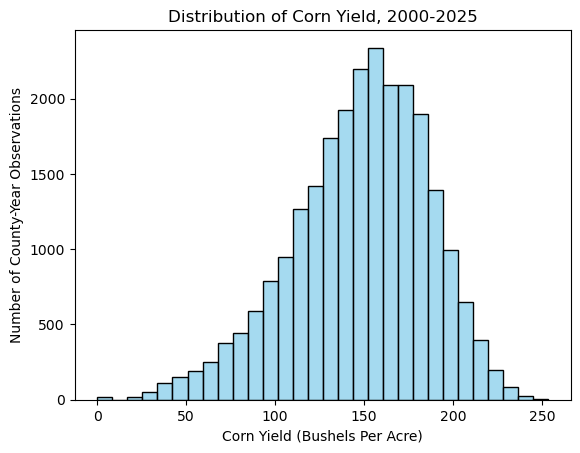

In [26]:
sns.histplot(data=yield_df, x='Value', bins=30, color='skyblue')

plt.xlabel('Corn Yield (Bushels Per Acre)')
plt.ylabel('Number of County-Year Observations')
plt.title('Distribution of Corn Yield, 2000-2025')

plt.show()

The corn yields from 2000-2025 have a single peak around 150-160 bushels per acre. Most of the observations are around 100-200 bushels per acre.

There is a little bit of a tail towards the left meaning there is some left skew. 

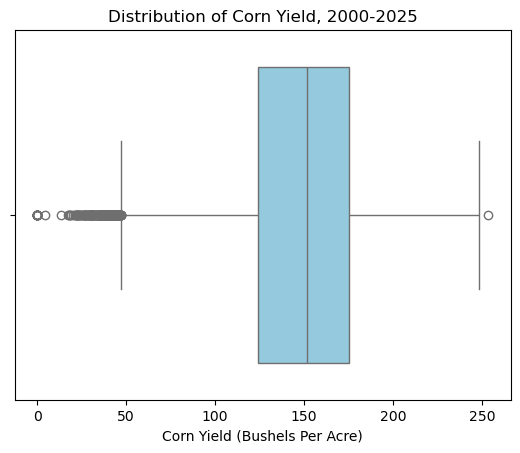

In [27]:
sns.boxplot(data=yield_df, x='Value', color='skyblue')

plt.xlabel('Corn Yield (Bushels Per Acre)')
plt.title('Distribution of Corn Yield, 2000-2025')

plt.show()

In [28]:
# Calculate IQR with pd.quantile
q1 = yield_df['Value'].quantile(q=0.25)
q2 = yield_df['Value'].quantile(q=0.5)
q3 = yield_df['Value'].quantile(q=0.75)

iqr = q3 - q1

low_outliers = q1 - (1.5 * iqr)
high_outliers = q3 + (1.5 * iqr)

print(f"Q1: {q1}")
print(f"Q2: {q2}")
print(f"Q3: {q3}")

print(f"Interquartile Range: {iqr:.2f}")
print(f"Low Outliers: {low_outliers:.2f}")
print(f"High Outliers: {high_outliers:.2f}")

Q1: 124.0
Q2: 151.8
Q3: 175.3
Interquartile Range: 51.30
Low Outliers: 47.05
High Outliers: 252.25


The median corn yield is 151.8 bushels per acre. the middle 50% of county year observations fall between 124 and 175.3 bushels per acre which gives an interquartile range of 51.3 bushels per acre.

Calculating the low and high outliers shows that yield below 47.05 and yield higher than 252.25 are potential outliers. There are more low yield outliers on the boxplot which is consistent with the histogram. 

In [29]:
yearly_yield = yield_df.groupby('year')['Value'].agg(['mean', 'median'])
yearly_yield

,mean,median
year,,
2000,127.573596,133.10
2001,126.356777,129.00
2002,112.486555,112.20
2003,125.598224,130.15
2004,145.327767,152.00
2005,132.854632,138.00
2006,135.442746,142.50
2007,136.538797,138.00
2008,141.408949,142.00


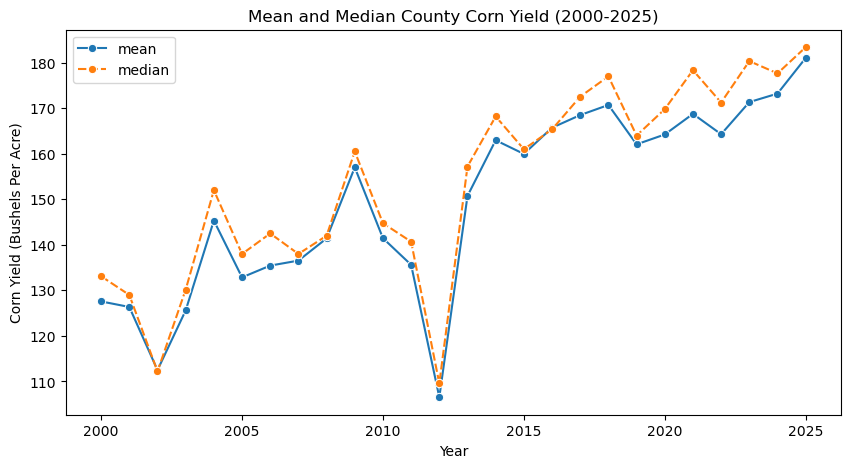

In [30]:
plt.figure(figsize=(10,5))

sns.lineplot(data=yearly_yield, marker='o')

plt.xlabel('Year')
plt.ylabel('Corn Yield (Bushels Per Acre)')
plt.title('Mean and Median County Corn Yield (2000-2025)')
plt.show()

The mean and median county corn yield has increased from 2000 - 2025. There is a big dip in the year 2012. This has the lowest mean and median with 106.53	and 109.55 bushels per acre respectively. This could be because of the drought of 2012, but could be other factors as well. The median is higher than the mean for most of the years. 

In [83]:
county_coverage = yield_df.groupby('year')['fips'].nunique()
county_coverage

year
2000    1068
2001    1055
2002    1071
2003    1070
2004    1048
2005    1047
2006    1027
2007    1031
2008     961
2009     972
2010    1024
2011     994
2012     996
2013     917
2014     935
2015     879
2016     914
2017     910
2018     807
2019     739
2020    1015
2021     878
2022     938
2023     884
2024     756
2025     708
Name: fips, dtype: int64

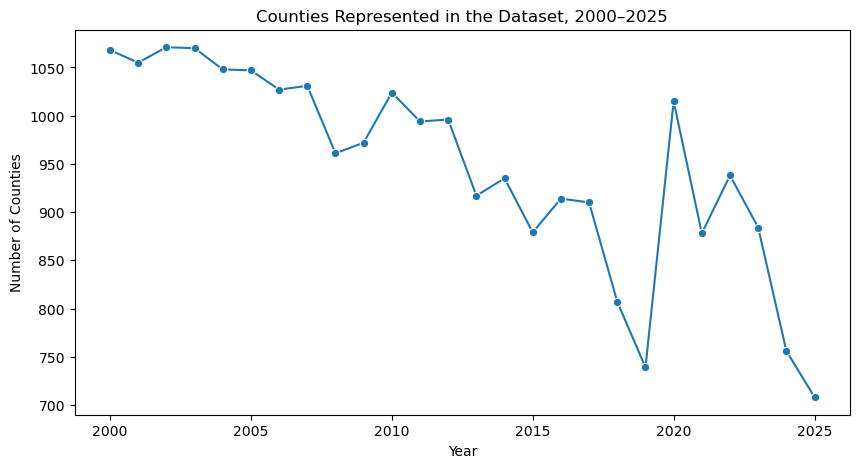

In [84]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=county_coverage, marker='o')

plt.xlabel('Year')
plt.ylabel('Number of Counties')
plt.title('Counties Represented in the Dataset, 2000–2025')

plt.show()

This section counts the distinct counties represented in each year of the final dataset.

Changes in coverage matter because annual yield summaries may compare different groups of counties. No missing cells does not mean every county has a record for every year.

In [31]:
state_yield = yield_df.groupby('state_alpha')['Value'].agg(['count', 'mean', 'median'])
state_yield.sort_values('median')

,count,mean,median
state_alpha,,,
ND,1054,106.567362,106.0
KS,2090,120.636555,120.0
SD,1363,118.348863,121.9
MO,1967,133.562176,136.1
MI,1485,136.071246,138.4
KY,2092,139.897562,142.0
WI,1577,147.063475,148.8
OH,2051,152.524281,155.2
MN,1867,158.578575,163.0


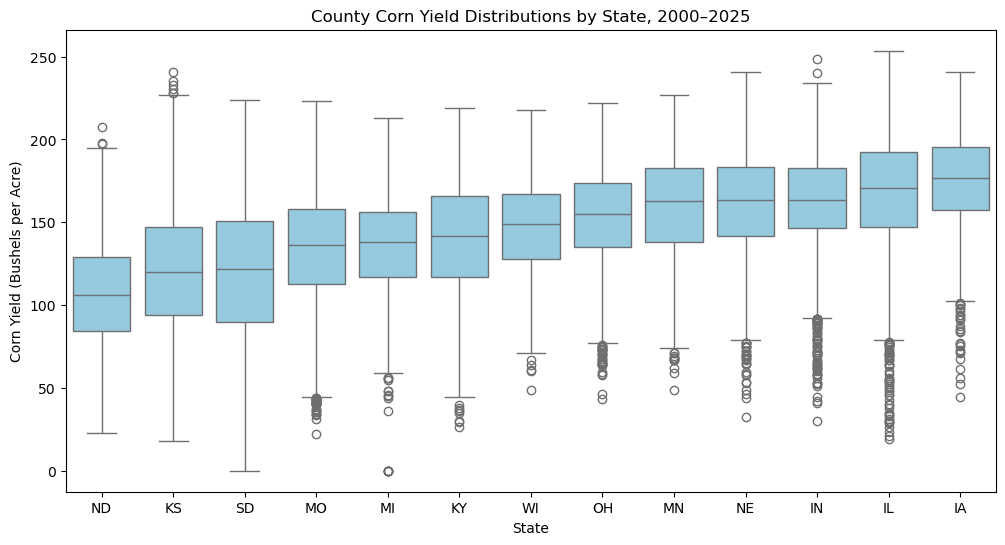

In [32]:
state_order = state_yield.sort_values('median').index

plt.figure(figsize=(12, 6))

sns.boxplot(data=yield_df, x='state_alpha', y='Value', order=state_order, color='skyblue')

plt.xlabel('State')
plt.ylabel('Corn Yield (Bushels per Acre)')
plt.title('County Corn Yield Distributions by State, 2000–2025')

plt.show()

The median county corn yeilds across all of the states are different. Iowa has the highest of 176.7 bushels per acres followed by Illinois and Indiana. North Dakota has the lowest median with 106.

Minnesota, Nebraska, and Indiana have all very similar medians from 163 - 163.6 bushels per acre. 

### Weather Columns

In [33]:
weather_df = df[['latitude', 'longitude', 'prcp_total_mm_m01', 'prcp_total_mm_m02', 'prcp_total_mm_m03', 'prcp_total_mm_m04', 'prcp_total_mm_m06', 'prcp_total_mm_m05', 'prcp_total_mm_m07', 'prcp_total_mm_m08', 'prcp_total_mm_m09', 'prcp_total_mm_m10', 'prcp_total_mm_m11', 'prcp_total_mm_m12', 'radiation_total_mj_m2_m01', 'radiation_total_mj_m2_m02', 'radiation_total_mj_m2_m03', 'radiation_total_mj_m2_m04', 'radiation_total_mj_m2_m05', 'radiation_total_mj_m2_m06', 'radiation_total_mj_m2_m07', 'radiation_total_mj_m2_m08', 'radiation_total_mj_m2_m09', 'radiation_total_mj_m2_m10', 'radiation_total_mj_m2_m11', 'radiation_total_mj_m2_m12', 'dayl_mean_s_m01', 'dayl_mean_s_m02', 'dayl_mean_s_m03', 'dayl_mean_s_m04', 'dayl_mean_s_m05', 'dayl_mean_s_m06', 'dayl_mean_s_m07', 'dayl_mean_s_m08', 'dayl_mean_s_m09', 'dayl_mean_s_m10', 'dayl_mean_s_m11', 'dayl_mean_s_m12', 'swe_mean_kg_m2_m01', 'swe_mean_kg_m2_m02', 'swe_mean_kg_m2_m03', 'swe_mean_kg_m2_m04', 'swe_mean_kg_m2_m05', 'swe_mean_kg_m2_m06', 'swe_mean_kg_m2_m07', 'swe_mean_kg_m2_m08', 'swe_mean_kg_m2_m09', 'swe_mean_kg_m2_m10', 'swe_mean_kg_m2_m11', 'swe_mean_kg_m2_m12', 'tmax_mean_c_m01', 'tmax_mean_c_m02', 'tmax_mean_c_m03', 'tmax_mean_c_m04', 'tmax_mean_c_m05', 'tmax_mean_c_m06', 'tmax_mean_c_m07', 'tmax_mean_c_m08', 'tmax_mean_c_m09', 'tmax_mean_c_m10', 'tmax_mean_c_m11', 'tmax_mean_c_m12', 'tmin_mean_c_m01', 'tmin_mean_c_m02', 'tmin_mean_c_m03', 'tmin_mean_c_m04', 'tmin_mean_c_m05', 'tmin_mean_c_m06', 'tmin_mean_c_m07', 'tmin_mean_c_m08', 'tmin_mean_c_m09', 'tmin_mean_c_m10', 'tmin_mean_c_m11', 'tmin_mean_c_m12', 'vp_mean_pa_m01', 'vp_mean_pa_m02', 'vp_mean_pa_m03', 'vp_mean_pa_m04', 'vp_mean_pa_m05', 'vp_mean_pa_m06', 'vp_mean_pa_m07', 'vp_mean_pa_m08', 'vp_mean_pa_m09', 'vp_mean_pa_m10', 'vp_mean_pa_m11', 'vp_mean_pa_m12']]

In [34]:
weather_df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,24644.0,41.299657,2.812696,36.211400,39.059800,40.988000,43.345900,48.814900
longitude,24644.0,-91.543901,5.702835,-103.846600,-96.177900,-91.479300,-86.446200,-80.748200
prcp_total_mm_m01,24644.0,46.268875,42.391356,0.000000,14.850000,32.025000,66.360000,283.480000
prcp_total_mm_m02,24644.0,48.823535,43.909309,0.000000,17.707500,36.840000,66.080000,343.800000
prcp_total_mm_m03,24644.0,68.422388,47.886767,0.000000,32.010000,60.490000,93.090000,444.310000
prcp_total_mm_m04,24644.0,95.190592,54.840617,0.000000,57.330000,87.870000,121.957500,493.550000
prcp_total_mm_m06,24644.0,116.753259,61.911087,0.000000,72.290000,106.540000,149.635000,552.690000
prcp_total_mm_m05,24644.0,117.017343,57.939928,0.000000,74.820000,110.435000,149.892500,479.270000
prcp_total_mm_m07,24644.0,103.169191,56.613045,0.000000,62.047500,95.170000,135.310000,467.300000
prcp_total_mm_m08,24644.0,95.501507,56.383040,0.000000,54.750000,86.880000,125.650000,525.070000


#### Montly Precipitation

In [35]:
precipitation_df = weather_df.filter(like='prcp_total_mm_m')
precipitation_df = precipitation_df.sort_index(axis=1) # It switched May and June for some reason
precipitation_df.head()

,prcp_total_mm_m01,prcp_total_mm_m02,prcp_total_mm_m03,prcp_total_mm_m04,prcp_total_mm_m05,prcp_total_mm_m06,prcp_total_mm_m07,prcp_total_mm_m08,prcp_total_mm_m09,prcp_total_mm_m10,prcp_total_mm_m11,prcp_total_mm_m12
0,34.40,12.52,72.53,87.60,60.80,96.56,193.54,63.92,21.33,45.96,51.32,45.52
1,84.40,1.79,131.10,116.13,84.56,73.25,167.55,76.04,35.55,50.71,80.39,31.00
2,65.39,70.35,62.52,46.69,84.57,43.74,135.72,41.17,142.25,116.69,34.14,71.28
3,15.79,55.01,83.58,86.99,105.62,92.28,132.16,106.45,84.79,43.38,16.28,72.79
4,42.22,28.07,59.93,79.89,136.86,142.80,124.35,76.54,19.16,174.18,9.24,29.04


In [36]:
precipitation_df.describe().T

,count,mean,std,min,25%,50%,75%,max
prcp_total_mm_m01,24644.0,46.268875,42.391356,0.0,14.8500,32.025,66.3600,283.48
prcp_total_mm_m02,24644.0,48.823535,43.909309,0.0,17.7075,36.840,66.0800,343.80
prcp_total_mm_m03,24644.0,68.422388,47.886767,0.0,32.0100,60.490,93.0900,444.31
prcp_total_mm_m04,24644.0,95.190592,54.840617,0.0,57.3300,87.870,121.9575,493.55
prcp_total_mm_m05,24644.0,117.017343,57.939928,0.0,74.8200,110.435,149.8925,479.27
prcp_total_mm_m06,24644.0,116.753259,61.911087,0.0,72.2900,106.540,149.6350,552.69
prcp_total_mm_m07,24644.0,103.169191,56.613045,0.0,62.0475,95.170,135.3100,467.30
prcp_total_mm_m08,24644.0,95.501507,56.383040,0.0,54.7500,86.880,125.6500,525.07
prcp_total_mm_m09,24644.0,79.910677,55.056457,0.0,39.1800,68.730,107.9600,412.13
prcp_total_mm_m10,24644.0,78.605745,52.378215,0.0,37.3075,69.370,111.1000,450.29


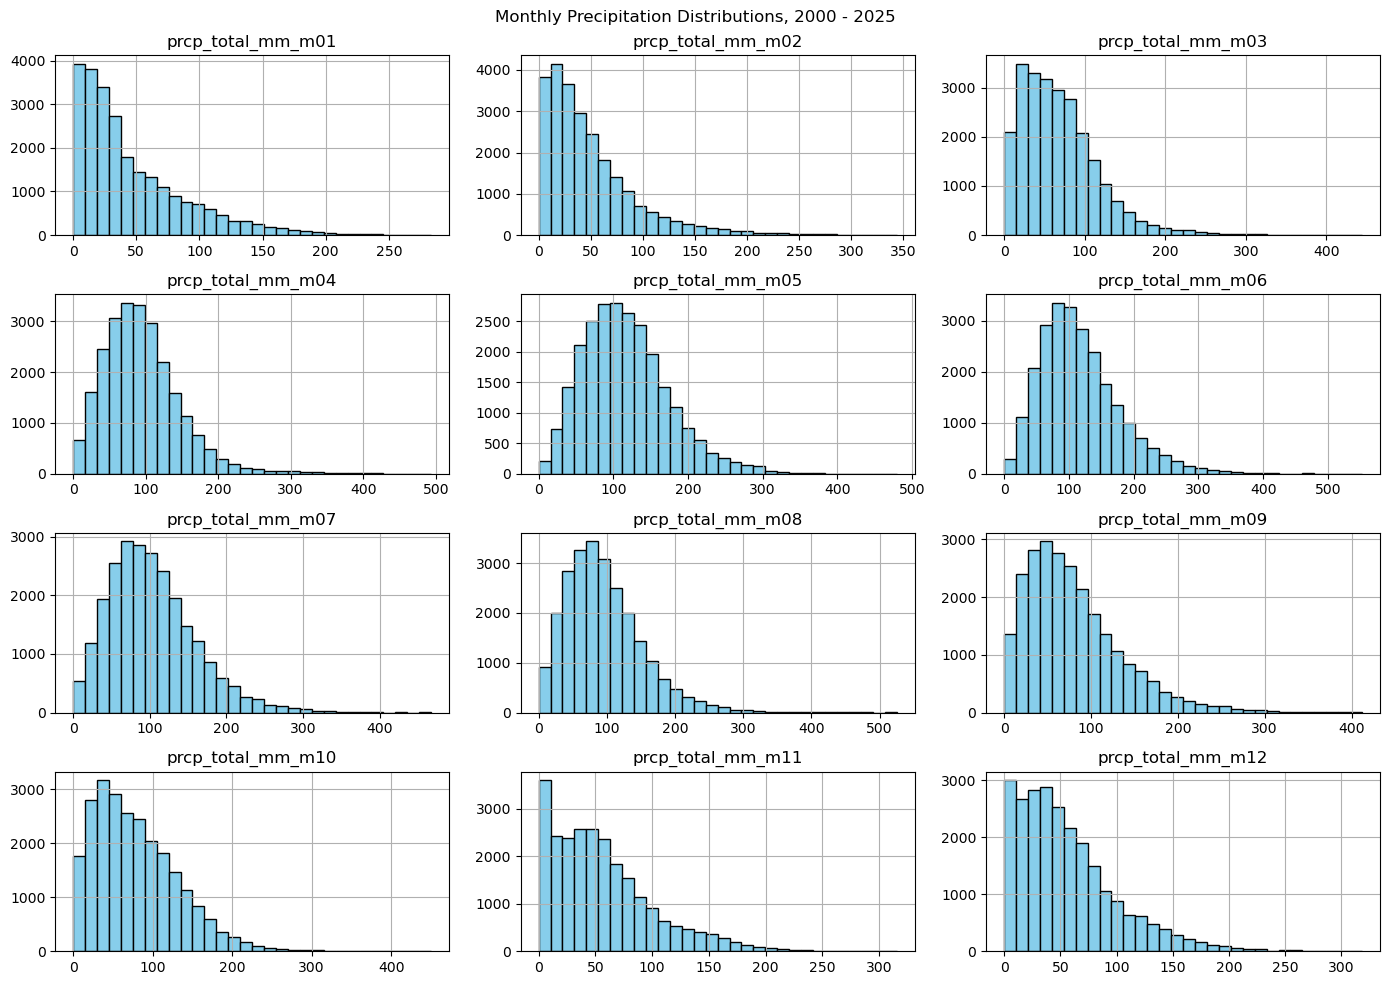

In [37]:
precipitation_df.hist(figsize=(14, 10), layout=(4, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Monthly Precipitation Distributions, 2000 - 2025')
plt.tight_layout()
plt.show()

These histograms show the precipitation in millimeters across each of the 12 months in a year. The x-axis shows the mongthly precipitation in mm and the y-axis shows the counts of county-year observations.

The two highest precipitation months are May and June with an average of 117.02 mm and 116.75 mm of precipitation. January and February have the lowest means of 46.27 mm and 48.82 mm. 

All of the distriutions are right skewed. There are no negative values in any of the months and every month has at least one zero value. 

#### Monthly Solar Radiation

In [38]:
radiation_df = weather_df.filter(like='radiation_total_mj_m2_m')
radiation_df = radiation_df.sort_index(axis=1)
radiation_df.head()

,radiation_total_mj_m2_m01,radiation_total_mj_m2_m02,radiation_total_mj_m2_m03,radiation_total_mj_m2_m04,radiation_total_mj_m2_m05,radiation_total_mj_m2_m06,radiation_total_mj_m2_m07,radiation_total_mj_m2_m08,radiation_total_mj_m2_m09,radiation_total_mj_m2_m10,radiation_total_mj_m2_m11,radiation_total_mj_m2_m12
0,227.630266,286.946158,430.942365,524.498705,645.706488,603.889934,551.007169,605.599072,493.847177,306.785162,192.900240,199.232859
1,170.571744,345.215084,386.755547,522.610584,624.050420,597.115231,600.126491,567.516489,472.032546,343.155034,157.903343,162.691174
2,161.456788,287.965088,414.172027,574.514832,696.389219,647.241240,595.050990,554.078212,402.702576,293.787202,226.698570,131.642355
3,210.507182,293.149375,400.476795,528.383194,589.249629,651.849662,579.821821,561.238240,450.632496,346.635479,199.381977,164.407795
4,195.169854,320.586191,455.706083,546.486177,579.408869,595.358759,586.801451,570.821666,480.442421,263.829616,222.671893,169.019995


In [39]:
radiation_df.describe().T

,count,mean,std,min,25%,50%,75%,max
radiation_total_mj_m2_m01,24644.0,216.207086,31.685696,118.075335,193.184263,217.495159,239.235711,320.805671
radiation_total_mj_m2_m02,24644.0,301.834308,28.762919,210.481294,281.867243,300.509910,320.283658,409.993476
radiation_total_mj_m2_m03,24644.0,457.896806,38.764175,347.705828,429.768284,456.801086,484.802022,603.127258
radiation_total_mj_m2_m04,24644.0,556.358550,37.661179,454.707036,530.583223,552.025345,577.139084,755.707516
radiation_total_mj_m2_m05,24644.0,624.746397,45.611717,492.644518,591.704933,622.324181,653.784823,877.916163
radiation_total_mj_m2_m06,24644.0,625.861801,40.267078,488.465348,597.713741,625.140612,651.267885,805.385537
radiation_total_mj_m2_m07,24644.0,626.377648,36.421552,495.631676,601.741125,624.315590,649.335827,803.796285
radiation_total_mj_m2_m08,24644.0,565.100751,32.961161,451.224433,542.593295,565.090577,587.840551,709.890912
radiation_total_mj_m2_m09,24644.0,450.175765,34.212202,322.231422,425.723122,453.874415,474.820907,559.011374
radiation_total_mj_m2_m10,24644.0,316.525772,40.170505,181.886075,288.316504,315.857940,344.757262,440.607789


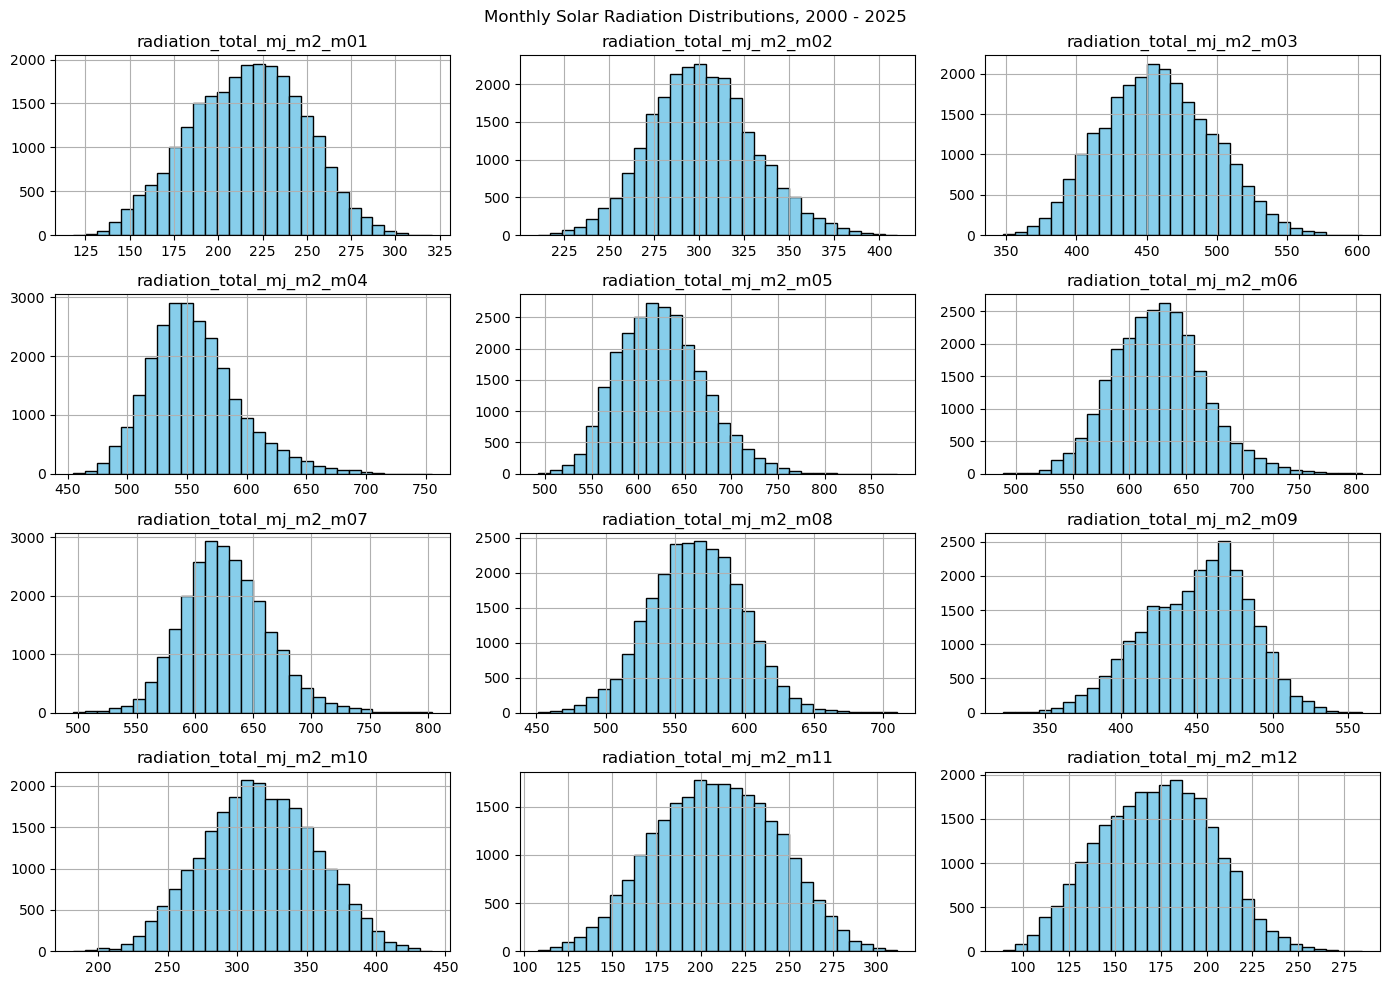

In [40]:
radiation_df.hist(figsize=(14, 10), layout=(4, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Monthly Solar Radiation Distributions, 2000 - 2025')
plt.tight_layout()
plt.show()

These variables represent total incoming shortwave solar energy during each month, measured in megajoules per square meter (MJ/m²). 

The average monthly solar radiation totals are highest in May, June, and July, ranging from approximately 624.75 to 626.38 MJ/m². December has the lowest mean at 172.92 MJ/m².

The monthly distributions generally have one main peak. Several appear roughly symmetric following that bell curve, while April through July show some right skew toward higher energy totals.

May has the largest standard deviation, at 45.61 MJ/m², indicating the greatest absolute spread across county-year observations. Also, all of the monthly minimum values are positive.

#### Monthly Daylight Duration

In [41]:
daylight_df = weather_df.filter(like='dayl_mean_s_m')
daylight_df = daylight_df.sort_index(axis=1)

daylight_hours_df = daylight_df / 3600
daylight_hours_df.columns = daylight_hours_df.columns.str.replace('dayl_mean_s_', 'dayl_mean_hours_', regex=False)

daylight_hours_df.head()

,dayl_mean_hours_m01,dayl_mean_hours_m02,dayl_mean_hours_m03,dayl_mean_hours_m04,dayl_mean_hours_m05,dayl_mean_hours_m06,dayl_mean_hours_m07,dayl_mean_hours_m08,dayl_mean_hours_m09,dayl_mean_hours_m10,dayl_mean_hours_m11,dayl_mean_hours_m12
0,9.381772,10.388151,11.717456,13.134963,14.333973,14.941028,14.654401,13.609386,12.235738,10.821197,9.632851,9.056242
1,9.381772,10.409793,11.764465,13.179474,14.365544,14.946368,14.630523,13.567727,12.188669,10.776942,9.601895,9.051351
2,9.381772,10.388151,11.717456,13.134963,14.333973,14.941028,14.654401,13.609386,12.235738,10.821197,9.632851,9.056242
3,9.381772,10.388151,11.717456,13.134963,14.333973,14.941028,14.654401,13.609386,12.235738,10.821197,9.632851,9.056242
4,9.381772,10.388151,11.717456,13.134963,14.333973,14.941028,14.654401,13.609386,12.235738,10.821197,9.632851,9.056242


In [42]:
daylight_hours_df.describe().T

,count,mean,std,min,25%,50%,75%,max
dayl_mean_hours_m01,24644.0,9.377112,0.278092,8.558246,9.187982,9.420005,9.598448,9.841559
dayl_mean_hours_m02,24644.0,10.391984,0.166192,9.899845,10.275561,10.419545,10.523392,10.684004
dayl_mean_hours_m03,24644.0,11.730065,0.034558,11.633592,11.707588,11.732529,11.753645,11.804671
dayl_mean_hours_m04,24644.0,13.148539,0.119414,12.940246,13.055687,13.129951,13.230935,13.533319
dayl_mean_hours_m05,24644.0,14.346447,0.247138,13.926491,14.151166,14.304955,14.510430,15.101428
dayl_mean_hours_m06,24644.0,14.948349,0.316175,14.420711,14.695500,14.897658,15.161178,15.888228
dayl_mean_hours_m07,24644.0,14.652610,0.281678,14.168454,14.429377,14.604613,14.845112,15.490710
dayl_mean_hours_m08,24644.0,13.600058,0.166158,13.297409,13.469766,13.573437,13.711327,14.097251
dayl_mean_hours_m09,24644.0,12.223061,0.030934,12.156470,12.203428,12.222502,12.243642,12.305674
dayl_mean_hours_m10,24644.0,10.807624,0.123924,10.409602,10.723537,10.828331,10.904955,11.023548


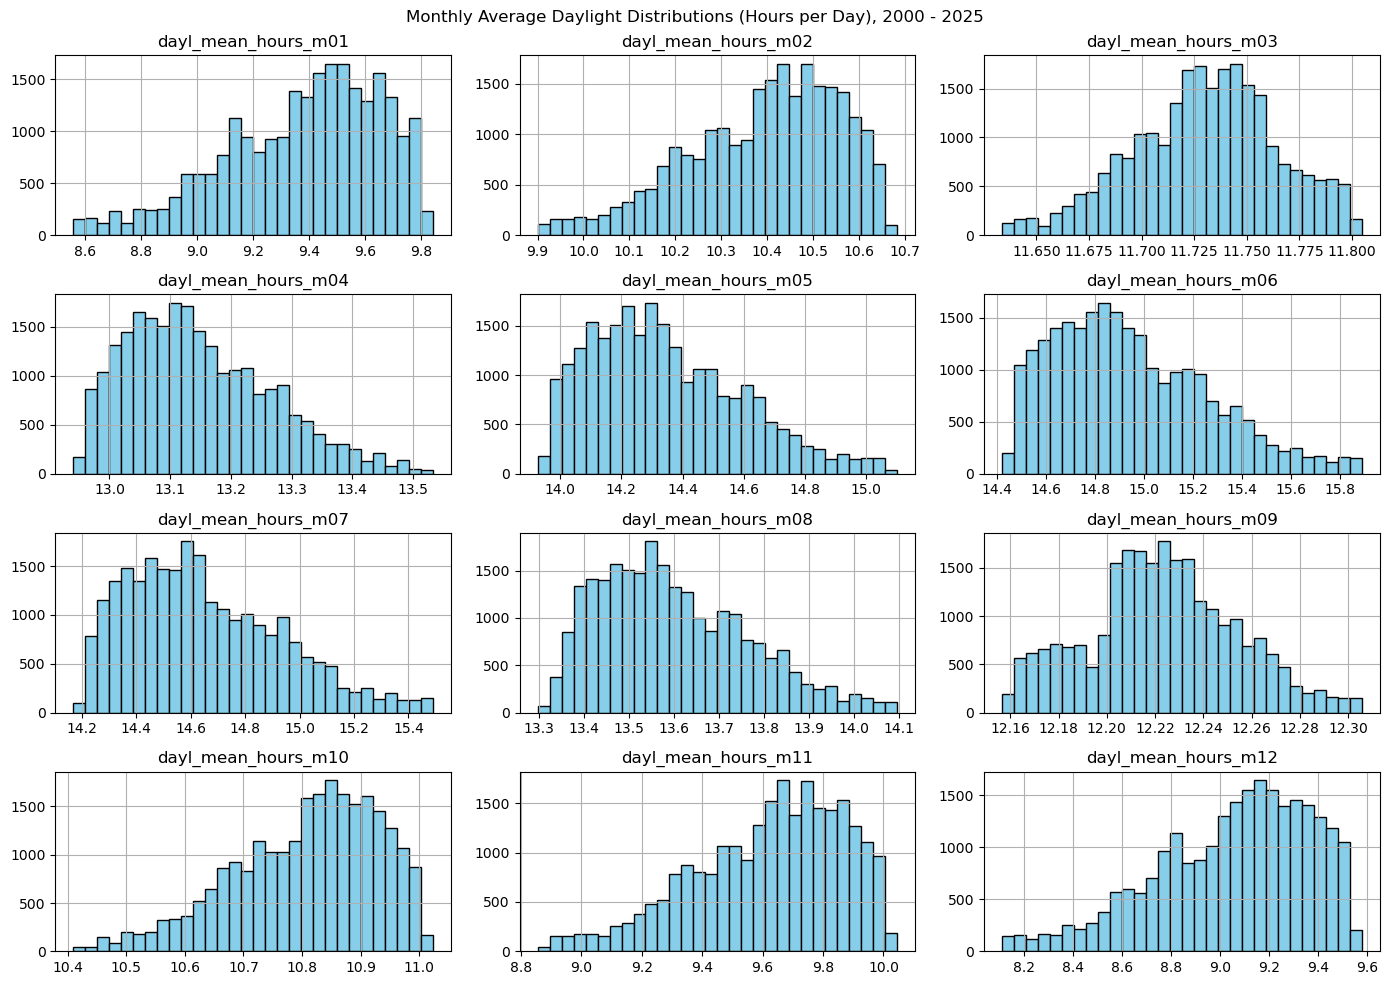

In [43]:
daylight_hours_df.hist(figsize=(14, 10), layout=(4, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Monthly Average Daylight Distributions (Hours per Day), 2000 - 2025')
plt.tight_layout()
plt.show()

These variables represent the average daily daylight duration within each month. The original measurements are in seconds per day. For these summaries and plots, they are converted to hours per day by dividing by 3,600.

Mean daily daylight duration is highest in June at approximately 14.95 hours and lowest in December at 9.05 hours.

Variation across county-year observations is smallest in March and September and greatest in June and December. September has a standard deviation of approximately 1.86 minutes (0.030934 * 60), compared with approximately 19 minutes (0.316484 * 60) in December.

Winter distributions generally have longer tails toward shorter daylight durations, while summer distributions have longer tails toward longer durations.

#### Snow Water Equivalent

In [44]:
snow_df = weather_df.filter(like='swe_mean_kg_m2_m')
snow_df = snow_df.sort_index(axis=1)
snow_df.head()

,swe_mean_kg_m2_m01,swe_mean_kg_m2_m02,swe_mean_kg_m2_m03,swe_mean_kg_m2_m04,swe_mean_kg_m2_m05,swe_mean_kg_m2_m06,swe_mean_kg_m2_m07,swe_mean_kg_m2_m08,swe_mean_kg_m2_m09,swe_mean_kg_m2_m10,swe_mean_kg_m2_m11,swe_mean_kg_m2_m12
0,8.714839,5.097500,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.375,19.991290
1,0.933548,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.957333
2,0.358710,0.639286,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000
3,0.560323,16.327143,7.635484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.091,1.340968
4,5.333226,28.988929,8.979677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.020968


In [45]:
snow_df.describe().T

,count,mean,std,min,25%,50%,75%,max
swe_mean_kg_m2_m01,24644.0,12.817183,16.543486,0.0,1.307339,6.166935,18.339032,181.168387
swe_mean_kg_m2_m02,24644.0,20.317367,23.047275,0.0,1.717386,12.188929,32.276857,231.710000
swe_mean_kg_m2_m03,24644.0,16.599896,26.265154,0.0,0.005403,3.800484,23.005081,280.397419
swe_mean_kg_m2_m04,24644.0,5.128292,16.363032,0.0,0.000000,0.000000,0.358917,269.253667
swe_mean_kg_m2_m05,24644.0,0.380191,3.729467,0.0,0.000000,0.000000,0.000000,169.305484
swe_mean_kg_m2_m06,24644.0,0.003933,0.323007,0.0,0.000000,0.000000,0.000000,41.874333
swe_mean_kg_m2_m07,24644.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
swe_mean_kg_m2_m08,24644.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
swe_mean_kg_m2_m09,24644.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
swe_mean_kg_m2_m10,24644.0,0.023334,0.221452,0.0,0.000000,0.000000,0.000000,6.418065


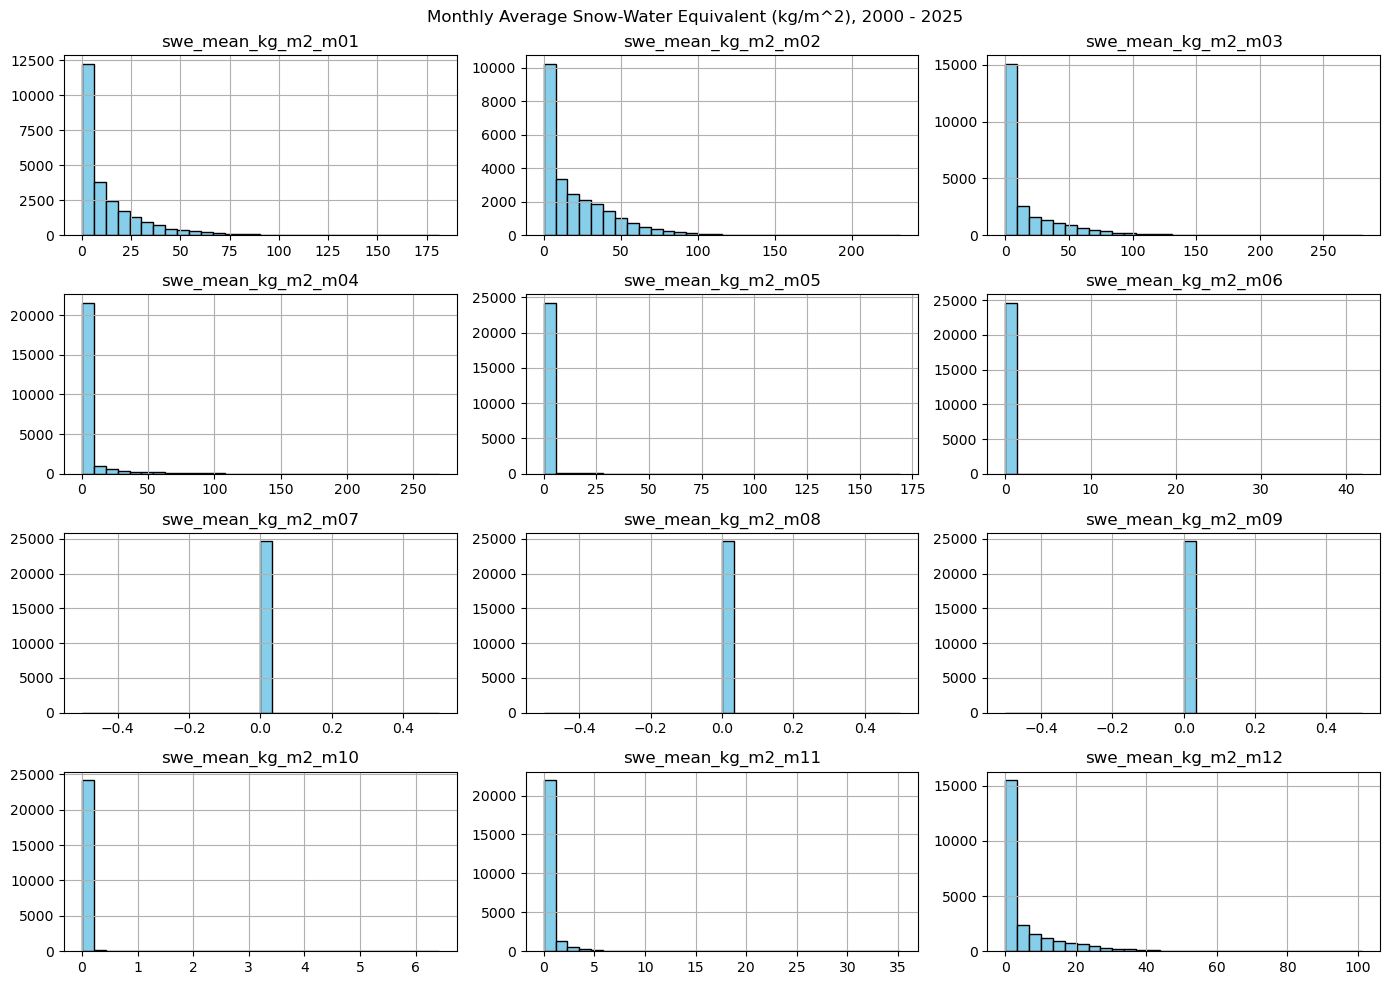

In [46]:
snow_df.hist(figsize=(14, 10), layout=(4, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Monthly Average Snow-Water Equivalent (kg/m^2), 2000 - 2025')
plt.tight_layout()
plt.show()

Snow-water equivalent (SWE) is the amount of water contained in the snowpack, measured in kilograms per square meter (kg/m²). Daymet estimates this quantity from temperature and precipitation. Think of it as the water that would remain if the snowpack melted. It is not snow depth or the amount of new snowfall.

Mean monthly snow-water equivalent is highest in February at approximately 20.32 kg/m², followed by March at 16.60 kg/m² and January at 12.82 kg/m².

The months with variation have strongly right skewed distributions, with many zero or small values and relatively few large values. March has the largest standard deviation at 26.27 kg/m².

July, August, and September contain only zeros and therefore have no variation in this dataset. June contains some positive values, despite having a mean close to zero.

No negative values appear in the summary. The constant columns are retained during EDA and will be addressed during model preparation.

#### Monthly Vapor Pressure

In [47]:
vapor_df = weather_df.filter(like='vp_mean_pa_m')
vapor_df = vapor_df.sort_index(axis=1)
vapor_df.head()

,vp_mean_pa_m01,vp_mean_pa_m02,vp_mean_pa_m03,vp_mean_pa_m04,vp_mean_pa_m05,vp_mean_pa_m06,vp_mean_pa_m07,vp_mean_pa_m08,vp_mean_pa_m09,vp_mean_pa_m10,vp_mean_pa_m11,vp_mean_pa_m12
0,274.333871,360.891429,669.014194,860.098667,1149.159032,1970.153333,2279.072258,1885.761613,1442.058333,1146.211935,628.067667,357.549355
1,400.525161,491.638966,652.787419,916.069000,1400.653548,1984.589000,1915.040968,1906.293871,1466.279667,978.475806,777.935667,462.975000
2,463.503871,426.782857,551.773226,786.947000,1208.501613,1535.258667,1945.164194,1912.132581,1583.150333,1067.424516,567.281000,614.017097
3,225.655484,294.260000,561.575484,759.192000,1471.162581,1827.592333,2026.516452,1920.243871,1510.500333,831.142258,627.178667,393.786774
4,372.242581,242.286071,594.198387,847.325333,1287.721935,2010.488000,2090.430323,2056.888065,1548.647000,1280.342903,565.100000,504.136452


In [48]:
vapor_df.describe().T

,count,mean,std,min,25%,50%,75%,max
vp_mean_pa_m01,24644.0,344.584196,118.602813,91.412258,257.070000,329.544677,419.707581,770.120000
vp_mean_pa_m02,24644.0,353.722043,138.537457,69.679286,241.885628,344.032679,447.034800,852.892500
vp_mean_pa_m03,24644.0,522.005559,200.292134,84.043548,372.631452,511.394677,655.682581,1306.850000
vp_mean_pa_m04,24644.0,757.236564,246.988560,153.379333,585.783167,767.745500,934.913667,1517.362333
vp_mean_pa_m05,24644.0,1199.100607,290.578833,263.736774,1008.830806,1211.288548,1405.645242,2163.205806
vp_mean_pa_m06,24644.0,1731.095781,298.289660,463.626667,1548.044583,1746.882167,1936.222333,2737.994667
vp_mean_pa_m07,24644.0,2000.412277,299.680529,612.769032,1802.153790,2003.823226,2206.897661,2947.784839
vp_mean_pa_m08,24644.0,1874.845454,282.811489,589.784516,1684.873952,1859.227742,2068.388629,2712.901935
vp_mean_pa_m09,24644.0,1438.836336,237.267583,388.617667,1285.802917,1439.530833,1595.977167,2299.902667
vp_mean_pa_m10,24644.0,933.330077,183.342283,258.033548,802.756048,926.538226,1052.381532,1532.883548


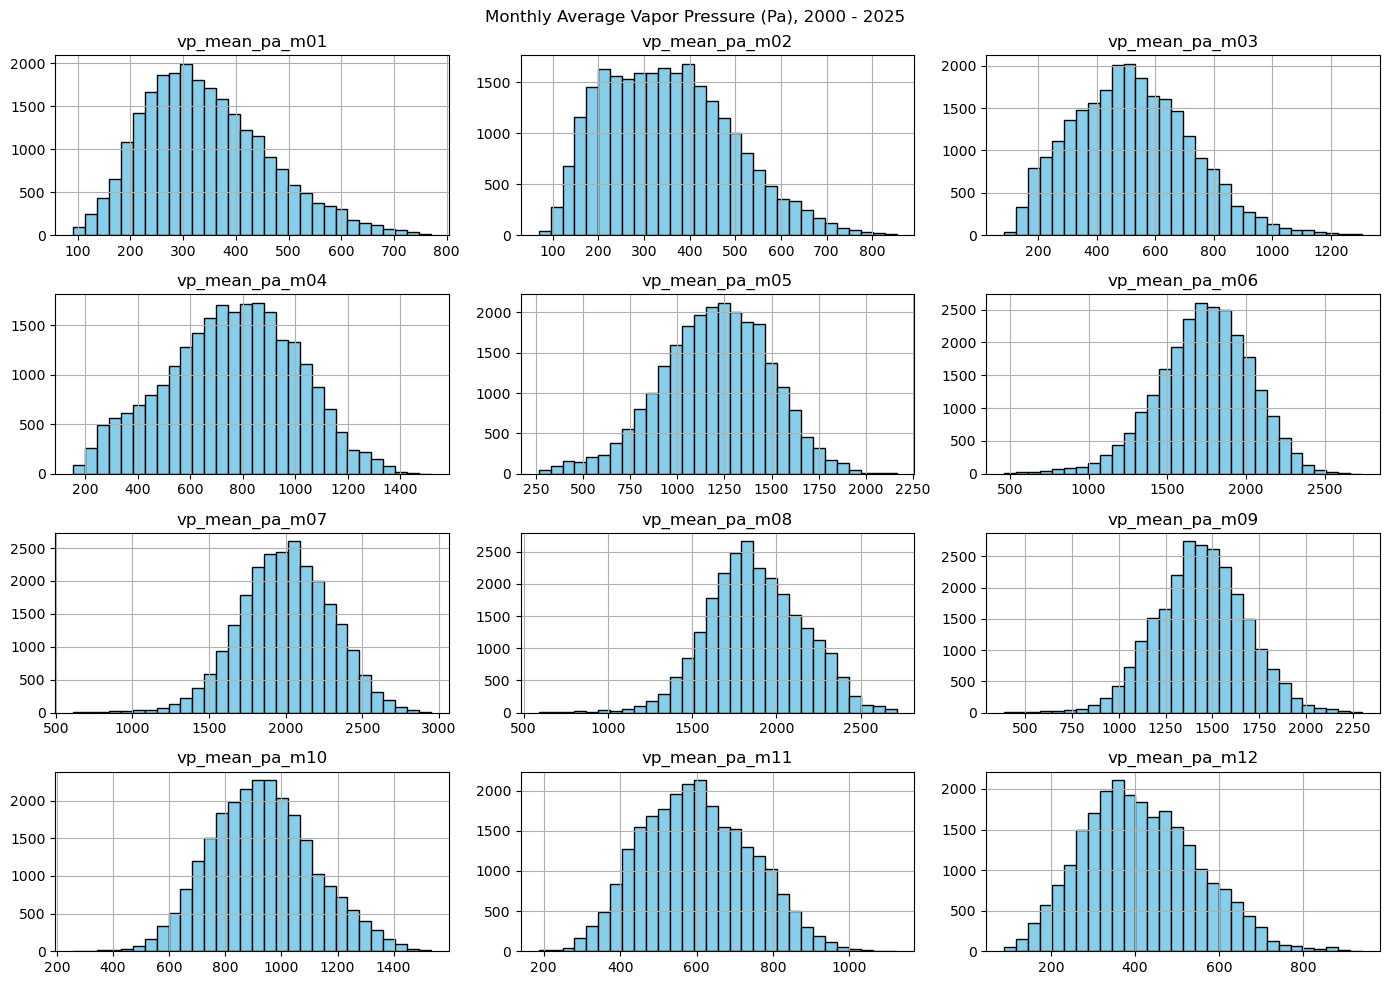

In [49]:
vapor_df.hist(figsize=(14, 10), layout=(4, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Monthly Average Vapor Pressure (Pa), 2000 - 2025')
plt.tight_layout()
plt.show()

These variables represent monthly averages of daily water-vapor pressure, measured in pascals (Pa). Vapor pressure describes the pressure exerted by water vapor in the air. It is different from relative humidity, which is expressed as a percentage.

Mean monthly vapor pressure increases from winter toward summer and then decreases toward winter. January has the lowest mean at approximately 344.58 Pa, while July has the highest at 2,000.41 Pa.

Absolute variation across county-year observations is greatest in June and July, with standard deviations of approximately 298.29 Pa and 299.68 Pa. January has the smallest standard deviation at 118.60 Pa.

Several winter distributions have tails toward higher vapor-pressure values. Many warmer-month distributions are more concentrated around a central peak, although their shapes are not perfectly symmetric.

#### Monthly Maximum Temperatures

In [50]:
max_temperature_df = weather_df.filter(like='tmax_mean_c_m')
max_temperature_df = max_temperature_df.sort_index(axis=1)
max_temperature_df.head()

,tmax_mean_c_m01,tmax_mean_c_m02,tmax_mean_c_m03,tmax_mean_c_m04,tmax_mean_c_m05,tmax_mean_c_m06,tmax_mean_c_m07,tmax_mean_c_m08,tmax_mean_c_m09,tmax_mean_c_m10,tmax_mean_c_m11,tmax_mean_c_m12
0,-1.161613,1.207143,13.530323,17.177667,22.325806,28.657333,29.462903,27.506452,27.218333,20.367742,9.991000,1.410645
1,-1.820000,9.925172,12.556774,16.907667,24.849355,28.628000,27.805484,27.678387,26.861000,21.775484,10.532333,3.418000
2,1.769677,5.738214,8.401935,17.709000,24.793226,28.444667,28.900645,28.032581,25.456333,17.505806,10.626667,6.262581
3,-3.410645,1.220357,9.614516,13.664667,23.210968,28.475333,28.174839,27.480323,24.344333,17.798710,10.376000,1.481935
4,-0.325161,-4.890000,11.679677,16.811667,20.811935,29.097333,27.815484,29.455484,27.616000,19.488710,9.402000,7.001935


In [51]:
max_temperature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
tmax_mean_c_m01,24644.0,0.924954,4.768180,-15.216774,-2.504032,0.922097,4.492016,15.687419
tmax_mean_c_m02,24644.0,2.879028,5.511668,-15.860714,-0.938670,3.077543,7.026875,17.380357
tmax_mean_c_m03,24644.0,10.049114,4.869771,-6.174839,6.710645,10.423710,13.580484,22.878710
tmax_mean_c_m04,24644.0,16.762028,3.599840,2.390333,14.412917,17.084167,19.455083,26.232667
tmax_mean_c_m05,24644.0,22.488549,2.638817,13.376129,20.649194,22.510806,24.332742,31.252258
tmax_mean_c_m06,24644.0,27.700849,2.343177,18.192000,26.077333,27.805000,29.342417,36.672333
tmax_mean_c_m07,24644.0,29.734523,2.406155,21.226129,28.060000,29.566935,31.212984,39.899032
tmax_mean_c_m08,24644.0,28.791145,2.406568,19.522581,27.123226,28.642258,30.257258,38.435806
tmax_mean_c_m09,24644.0,25.271405,2.627531,16.467000,23.461167,25.283167,27.201000,33.087667
tmax_mean_c_m10,24644.0,17.748185,3.425222,4.147419,15.608065,18.011129,20.259677,27.746129


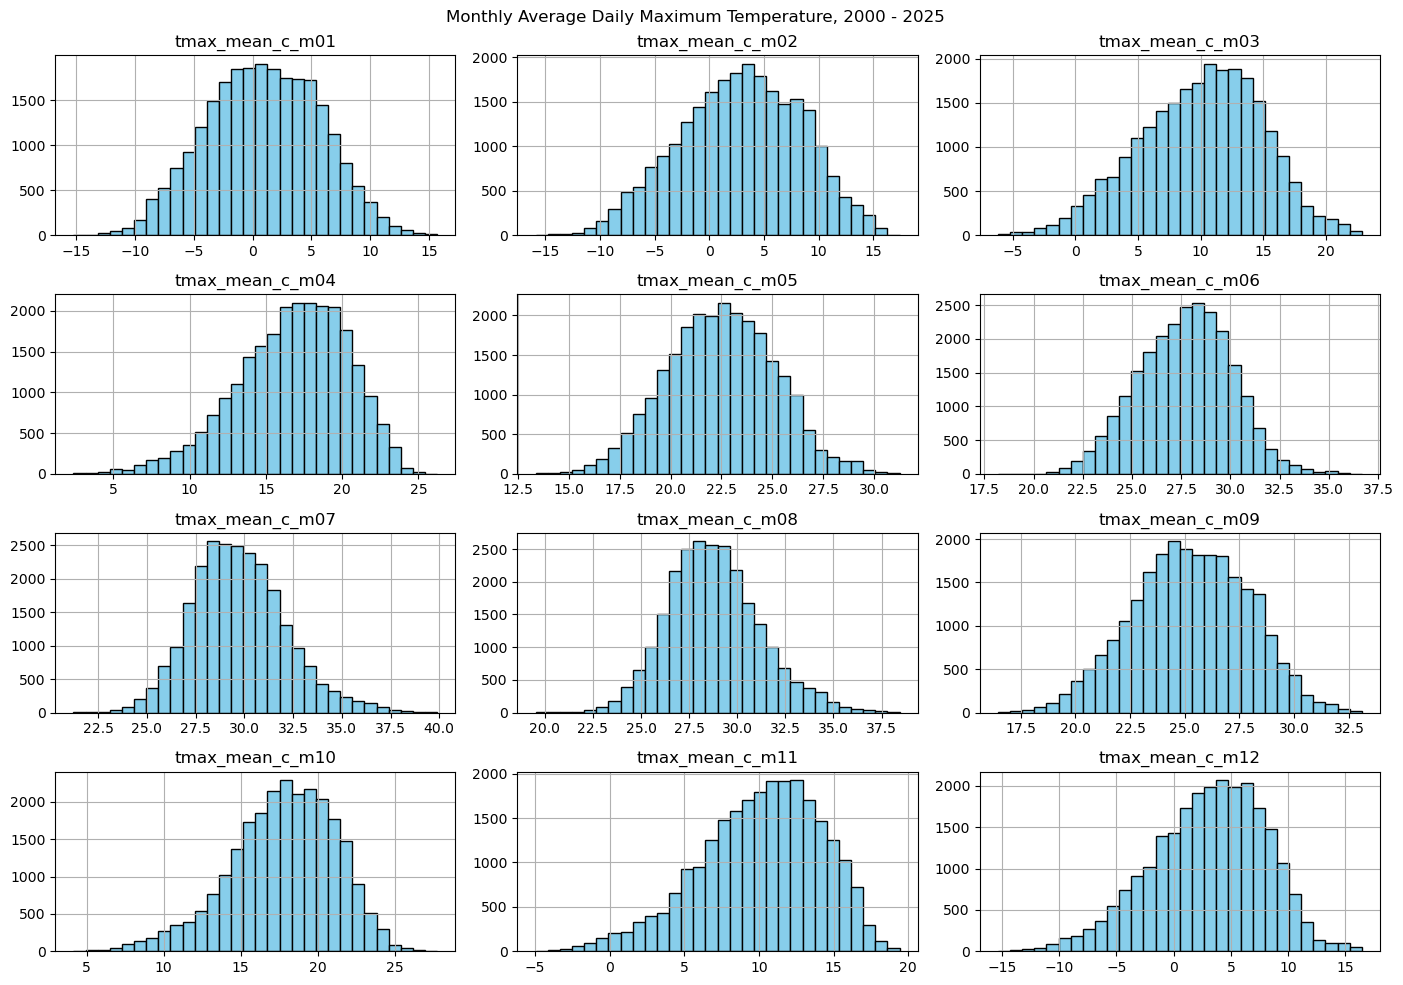

In [52]:
max_temperature_df.hist(figsize=(14, 10), layout=(4, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Monthly Average Daily Maximum Temperature, 2000 - 2025')
plt.tight_layout()
plt.show()

The monthly average daily maximum temperatures follow the normal seasonal patterns throughout the months. January has the lowest mean at 0.92 degrees Celsius (33.66 Fahrenheit) and July has the highest average at 29.73 degreec Celsius (85.51 Fahrenheit).

The winter months have more variation than the summer months. This is because February has the largest standard deviation at 5.51 C and June has the smallest at 2.34 C. 

ALmost every month has a normal bell curve. Some have a little bit of a tail, but they generally have a bell shape. 

The negative winter values mean that the daily maximum temperatures averaged below freezing for those county-month observations.

#### Monthly Minimum Temperatures

In [53]:
min_temperature_df = weather_df.filter(like='tmin_mean_c_m')
min_temperature_df = min_temperature_df.sort_index(axis=1)
min_temperature_df.head()

,tmin_mean_c_m01,tmin_mean_c_m02,tmin_mean_c_m03,tmin_mean_c_m04,tmin_mean_c_m05,tmin_mean_c_m06,tmin_mean_c_m07,tmin_mean_c_m08,tmin_mean_c_m09,tmin_mean_c_m10,tmin_mean_c_m11,tmin_mean_c_m12
0,-11.555161,-8.573214,0.673548,4.555667,9.293226,16.975000,19.555161,16.159355,12.137000,8.218065,-0.005667,-8.658710
1,-8.052581,-3.427586,0.580645,5.125667,11.786452,17.079000,16.672258,16.336774,12.434000,5.986129,2.430000,-4.954667
2,-4.446129,-5.809286,-1.762581,3.211000,9.859677,14.143667,17.129032,16.512258,13.578000,7.088710,-1.584667,-0.526452
3,-13.956452,-10.377500,-1.516129,2.408667,12.074516,15.803000,17.590323,16.659032,12.548667,3.743226,-0.794000,-7.512258
4,-7.219032,-14.222143,-0.039355,4.388667,9.874194,17.236333,18.084839,17.709032,13.279333,9.830323,-1.525000,-3.084839


In [54]:
min_temperature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
tmin_mean_c_m01,24644.0,-9.288938,4.737142,-26.048710,-12.324919,-9.026452,-5.995081,2.536452
tmin_mean_c_m02,24644.0,-8.480922,5.185833,-27.325000,-11.863571,-7.848393,-4.641435,3.520357
tmin_mean_c_m03,24644.0,-2.242256,4.158304,-18.008387,-4.828145,-2.047419,0.639194,10.077097
tmin_mean_c_m04,24644.0,3.449177,3.180074,-8.224000,1.266583,3.565667,5.734917,12.422000
tmin_mean_c_m05,24644.0,9.717267,2.778784,0.320645,7.747661,9.718226,11.729597,18.573871
tmin_mean_c_m06,24644.0,15.238411,2.308143,5.805667,13.743333,15.375167,16.896417,22.515667
tmin_mean_c_m07,24644.0,17.487554,2.200517,9.624194,15.979032,17.541129,19.076774,23.924516
tmin_mean_c_m08,24644.0,16.331819,2.249197,8.190645,14.802903,16.237097,17.930000,22.900323
tmin_mean_c_m09,24644.0,11.910802,2.438396,3.239667,10.348333,12.016833,13.608917,19.654667
tmin_mean_c_m10,24644.0,5.147509,2.750545,-6.096774,3.301855,5.276774,7.038790,12.722903


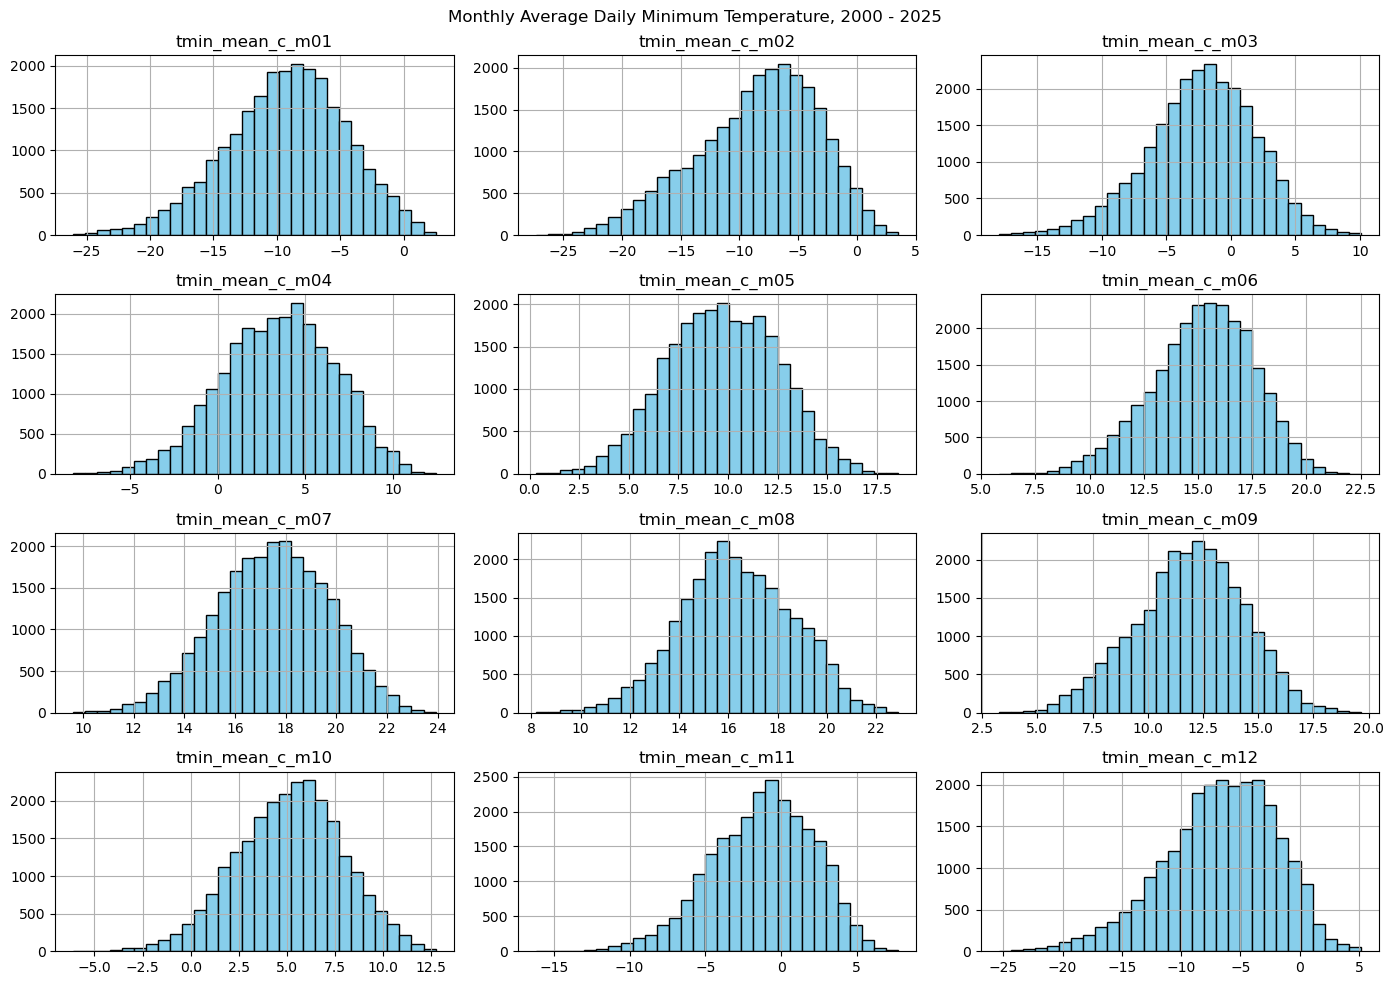

In [55]:
min_temperature_df.hist(figsize=(14, 10), layout=(4, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Monthly Average Daily Minimum Temperature, 2000 - 2025')
plt.tight_layout()
plt.show()

The monthly average daily minimum temperatures follow the normal seasonal patterns throughout the months. January has the lowest mean at -9.29 degrees Celsius (15.28 Fahrenheit) and July has the highest average at 17.49 degreec Celsius (63.48 Fahrenheit).

The winter months have more variation than the summer months. This is because February has the largest standard deviation at 5.19 C and July has the smallest at 2.20 C. 

Almost every month has a normal bell curve. Some have a little bit of a tail, but they generally have a bell shape. 

### Soil Columns

In [56]:
soil_cols = ['sand_pct_0_30cm', 'silt_pct_0_30cm', 'clay_pct_0_30cm', 'organic_matter_pct_0_30cm', 'ph_0_30cm', 'bulk_density_g_cm3_0_30cm', 'ksat_um_s_0_30cm', 'available_water_storage_cm_0_100cm', 'slope_pct']

In [57]:
soil_unique = df.groupby('fips')[soil_cols].nunique(dropna=False)
soil_unique.max()

sand_pct_0_30cm                       1
silt_pct_0_30cm                       1
clay_pct_0_30cm                       1
organic_matter_pct_0_30cm             1
ph_0_30cm                             1
bulk_density_g_cm3_0_30cm             1
ksat_um_s_0_30cm                      1
available_water_storage_cm_0_100cm    1
slope_pct                             1
dtype: int64

In [58]:
soil_df = df[['fips', 'state_alpha', 'county_name'] + soil_cols].drop_duplicates(subset='fips').copy()

soil_df = soil_df.reset_index(drop=True)

soil_df.head()

,fips,state_alpha,county_name,sand_pct_0_30cm,silt_pct_0_30cm,clay_pct_0_30cm,organic_matter_pct_0_30cm,ph_0_30cm,bulk_density_g_cm3_0_30cm,ksat_um_s_0_30cm,available_water_storage_cm_0_100cm,slope_pct
0,17011,IL,BUREAU,12.944472,62.969536,23.948762,3.691334,6.516119,1.363566,11.164841,18.336345,4.666624
1,17015,IL,CARROLL,10.767542,66.937202,22.294889,2.296730,6.310671,1.375260,11.187986,18.969111,8.918364
2,17073,IL,HENRY,11.993837,63.480373,24.360882,3.136311,6.379460,1.359200,11.433616,18.493254,5.463905
3,17085,IL,JO DAVIESS,10.397321,67.216687,22.385992,1.870301,6.375874,1.386045,10.873932,17.420200,12.662385
4,17103,IL,LEE,23.489228,53.284920,23.111808,3.804555,6.502960,1.371849,14.121940,17.226998,2.549010


In [59]:
soil_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sand_pct_0_30cm,1124.0,27.394495,18.836580,5.245822,13.564325,21.301625,34.352819,93.898612
silt_pct_0_30cm,1124.0,49.352980,14.565248,2.790688,40.446471,53.278339,59.993158,73.079272
clay_pct_0_30cm,1124.0,22.996201,7.251033,3.295454,19.346451,23.567893,27.683792,55.165325
organic_matter_pct_0_30cm,1124.0,3.934940,4.072161,0.661647,1.828595,2.581938,4.102556,44.840709
ph_0_30cm,1124.0,6.378917,0.583944,4.877296,6.034539,6.367188,6.748678,7.653986
bulk_density_g_cm3_0_30cm,1124.0,1.367856,0.073322,0.759382,1.339123,1.375609,1.408838,1.580268
ksat_um_s_0_30cm,1124.0,16.033366,16.872291,1.619028,7.196145,9.675543,16.446702,119.688843
available_water_storage_cm_0_100cm,1124.0,15.665005,2.781489,6.550572,13.972107,16.097453,17.614635,29.221872
slope_pct,1124.0,7.247448,6.335491,0.431607,3.081730,5.274561,9.053758,42.425691


#### Soil Texture

In [60]:
texture_df = soil_df[['sand_pct_0_30cm', 'silt_pct_0_30cm', 'clay_pct_0_30cm']]
texture_df.head()

,sand_pct_0_30cm,silt_pct_0_30cm,clay_pct_0_30cm
0,12.944472,62.969536,23.948762
1,10.767542,66.937202,22.294889
2,11.993837,63.480373,24.360882
3,10.397321,67.216687,22.385992
4,23.489228,53.284920,23.111808


In [61]:
texture_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sand_pct_0_30cm,1124.0,27.394495,18.836580,5.245822,13.564325,21.301625,34.352819,93.898612
silt_pct_0_30cm,1124.0,49.352980,14.565248,2.790688,40.446471,53.278339,59.993158,73.079272
clay_pct_0_30cm,1124.0,22.996201,7.251033,3.295454,19.346451,23.567893,27.683792,55.165325


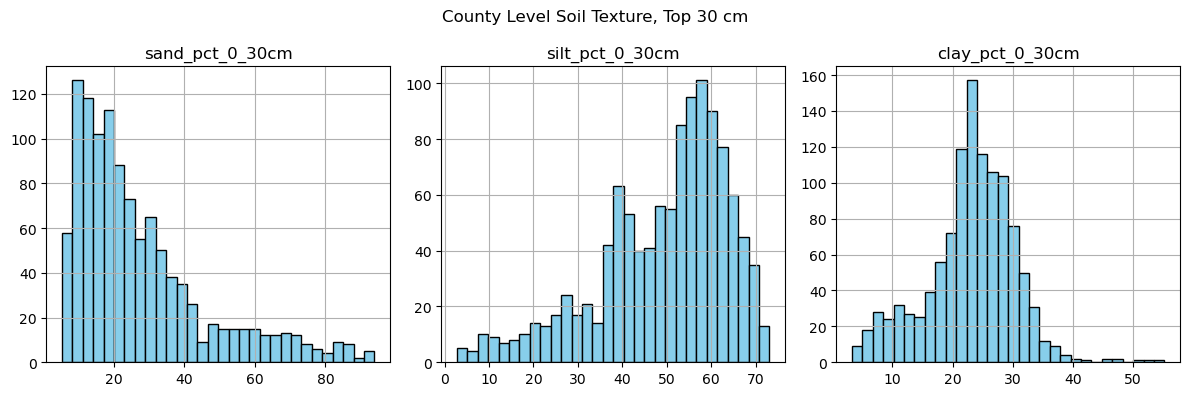

In [62]:
texture_df.hist(figsize=(12, 4), layout=(1, 3), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('County Level Soil Texture, Top 30 cm')
plt.tight_layout()
plt.show()

Across the 1,124 counties, silt has the highest mean percentage at 49.35%, followed by sand at 27.39% and clay at 23.00%.

Sand has the greatest variation across counties and a right-skewed distribution. Silt has a left-skewed distribution, while clay is more concentrated around its central values.

All observed percentages fall between 0% and 100%.

Each county receives equal weight in these summaries. The values represent county-level averages and do not describe every field within a county or establish a relationship with corn yield.

#### Soil Organic Matter

In [63]:
soil_df['organic_matter_pct_0_30cm'].describe()

count    1124.000000
mean        3.934940
std         4.072161
min         0.661647
25%         1.828595
50%         2.581938
75%         4.102556
max        44.840709
Name: organic_matter_pct_0_30cm, dtype: float64

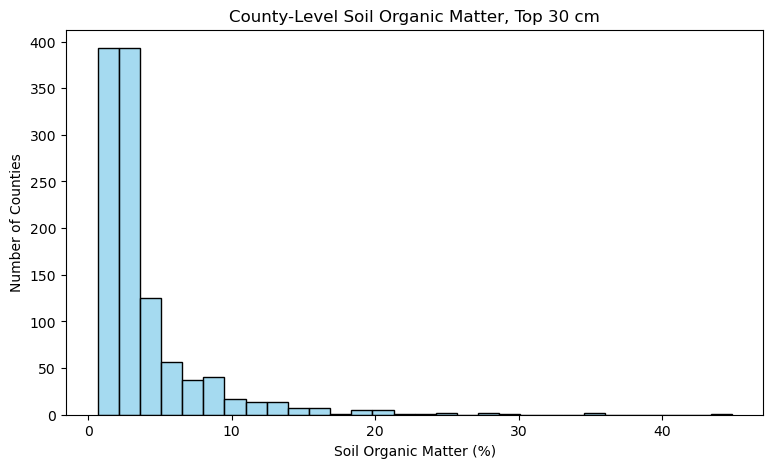

In [64]:
plt.figure(figsize=(9, 5))

sns.histplot(data=soil_df, x='organic_matter_pct_0_30cm', bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Soil Organic Matter (%)')
plt.ylabel('Number of Counties')
plt.title('County-Level Soil Organic Matter, Top 30 cm')

plt.show()

This variable represents the weighted average organic matter percentage in the upper 30 cm of soil.

The summary and histogram use one observation per county. County averages do not describe every individual field within a county.

County-level organic matter percentages are strongly right-skewed. Most counties have relatively low percentages, while a small number have much higher values.

The median is approximately 2.58%, and the middle 50% of counties fall between 1.83% and 4.10%. The mean is higher, at 3.93%, reflecting the influence of the upper tail.

#### Soil pH

In [67]:
soil_df['ph_0_30cm'].describe()

count    1124.000000
mean        6.378917
std         0.583944
min         4.877296
25%         6.034539
50%         6.367188
75%         6.748678
max         7.653986
Name: ph_0_30cm, dtype: float64

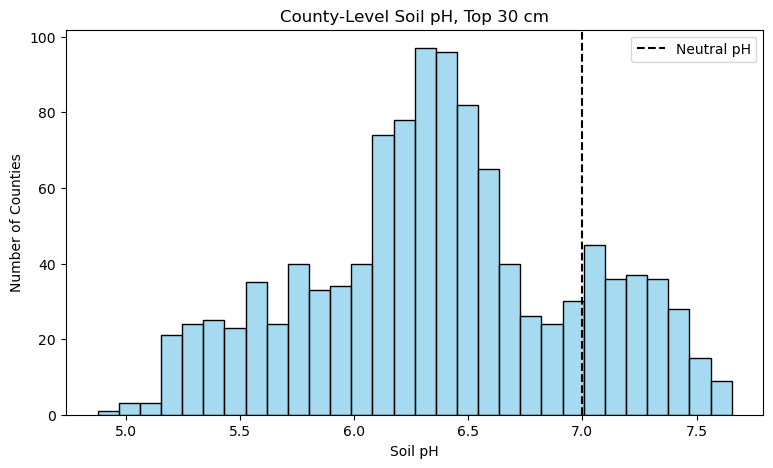

In [69]:
plt.figure(figsize=(9, 5))

sns.histplot(data=soil_df, x='ph_0_30cm', bins=30, color='skyblue', edgecolor='black')

plt.axvline(7, color='black', linestyle='--', label='Neutral pH')
plt.legend()

plt.xlabel('Soil pH')
plt.ylabel('Number of Counties')
plt.title('County-Level Soil pH, Top 30 cm')

plt.show()

This variable represents the weighted average soil pH in the upper 30 cm. Values below 7 indicate acidic conditions, 7 is neutral, and values above 7 indicate alkaline conditions.

The mean county-level soil pH is approximately 6.38, and the median is 6.37. The middle 50% of county averages fall between 6.03 and 6.75.

The histogram has its main concentration around pH 6.3–6.5. Values range from approximately 4.88 to 7.65, covering both acidic and alkaline county averages.

At least 75% of county averages are below pH 7. However, these averages may hide differences among soils within each county.

#### Soil Bulk Density

In [70]:
soil_df['bulk_density_g_cm3_0_30cm'].describe()

count    1124.000000
mean        1.367856
std         0.073322
min         0.759382
25%         1.339123
50%         1.375609
75%         1.408838
max         1.580268
Name: bulk_density_g_cm3_0_30cm, dtype: float64

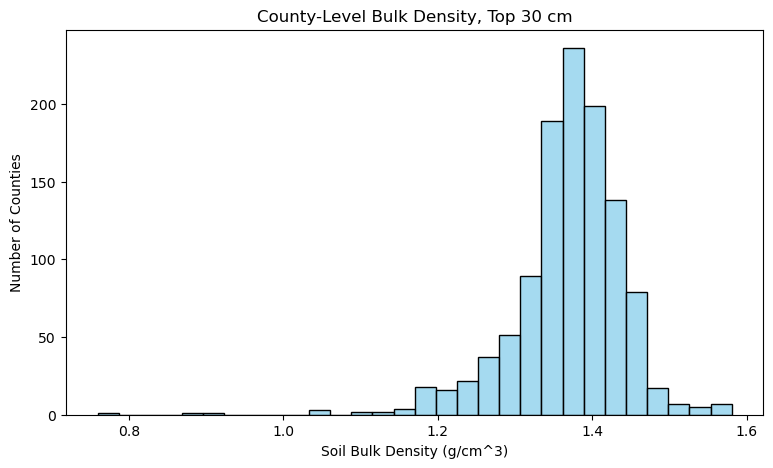

In [72]:
plt.figure(figsize=(9, 5))

sns.histplot(data=soil_df, x='bulk_density_g_cm3_0_30cm', bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Soil Bulk Density (g/cm^3)')
plt.ylabel('Number of Counties')
plt.title('County-Level Bulk Density, Top 30 cm')

plt.show()

Bulk density describes the dry mass of soil per unit of total volume, including pore spaces, measured in g/cm³. This variable represents the weighted average bulk density in the upper 30 cm. Each county contributes one observation.

County-level bulk density values are concentrated around 1.35–1.40 g/cm³. The mean is approximately 1.368 g/cm³, and the median is 1.376 g/cm³.

The middle 50% of county averages fall between 1.339 and 1.409 g/cm³. Values range from 0.759 to 1.580 g/cm³.

The distribution is left-skewed, with relatively few low values extending the lower tail. These values are not automatically treated as errors.

#### Saturated Hydraulic Conductivity

In [74]:
soil_df['ksat_um_s_0_30cm'].describe()

count    1124.000000
mean       16.033366
std        16.872291
min         1.619028
25%         7.196145
50%         9.675543
75%        16.446702
max       119.688843
Name: ksat_um_s_0_30cm, dtype: float64

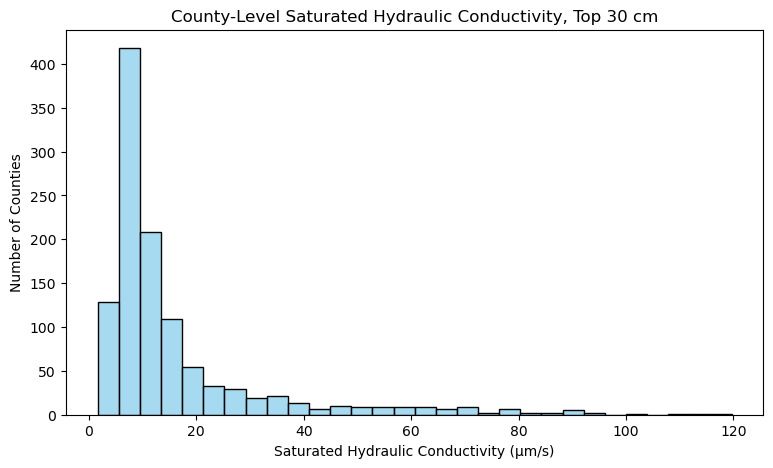

In [76]:
plt.figure(figsize=(9, 5))

sns.histplot(data=soil_df, x='ksat_um_s_0_30cm', bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Saturated Hydraulic Conductivity (µm/s)')
plt.ylabel('Number of Counties')
plt.title('County-Level Saturated Hydraulic Conductivity, Top 30 cm')

plt.show()

Saturated hydraulic conductivity (Ksat) describes how readily water moves through saturated soil. This variable represents the weighted average Ksat in the upper 30 cm, measured in micrometers per second (µm/s). Higher values indicate greater ability to transmit water under the same hydraulic gradient. Ksat does not measure water-storage capacity.

County-level Ksat values are strongly right-skewed. Most counties have relatively low values, while a small number have much higher conductivity.

The median is approximately 9.68 µm/s, and the middle 50% of county averages fall between 7.20 and 16.45 µm/s. The mean is higher, at 16.03 µm/s, reflecting the influence of the upper tail.

Values range from approximately 1.62 to 119.69 µm/s. No zero or negative values appear in the summary.

#### Available Water Storage

In [77]:
soil_df['available_water_storage_cm_0_100cm'].describe()

count    1124.000000
mean       15.665005
std         2.781489
min         6.550572
25%        13.972107
50%        16.097453
75%        17.614635
max        29.221872
Name: available_water_storage_cm_0_100cm, dtype: float64

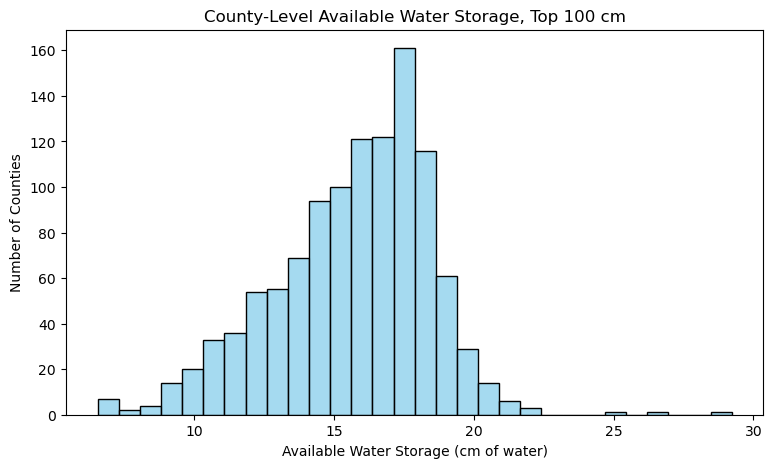

In [79]:
plt.figure(figsize=(9, 5))

sns.histplot(data=soil_df, x='available_water_storage_cm_0_100cm', bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Available Water Storage (cm of water)')
plt.ylabel('Number of Counties')
plt.title('County-Level Available Water Storage, Top 100 cm')

plt.show()

This variable represents the estimated amount of plant-available water that can be stored in the upper 100 cm of soil, expressed in centimeters of water. It describes storage capacity, not the actual soil moisture present at a particular time.

County-level available water storage is concentrated around 14–19 cm of water in the upper 100 cm of soil.

The mean is approximately 15.67 cm, and the median is 16.10 cm. The middle 50% of county averages fall between 13.97 and 17.61 cm.

The main distribution extends farther toward lower values, although a few isolated high values are also present. Values range from approximately 6.55 to 29.22 cm, with no zero or negative values.

#### Land Slope

In [80]:
soil_df['slope_pct'].describe()

count    1124.000000
mean        7.247448
std         6.335491
min         0.431607
25%         3.081730
50%         5.274561
75%         9.053758
max        42.425691
Name: slope_pct, dtype: float64

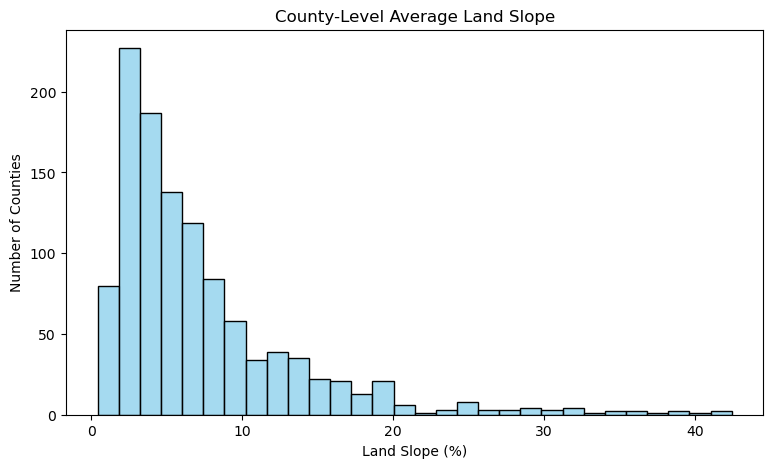

In [82]:
plt.figure(figsize=(9, 5))

sns.histplot(data=soil_df, x='slope_pct', bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Land Slope (%)')
plt.ylabel('Number of Counties')
plt.title('County-Level Average Land Slope')

plt.show()

This variable represents the weighted average land slope within each county, expressed as a percentage. Percent slope is the vertical change divided by the horizontal distance, multiplied by 100. Higher values indicate steeper land.

County-level average slopes are strongly right-skewed. Most counties have relatively low averages, while a small number have much steeper averages.

The mean slope is approximately 7.25%, and the median is 5.27%. The middle 50% of county averages fall between 3.08% and 9.05%.

Values range from approximately 0.43% to 42.43%. The upper tail pulls the mean above the median.